# UK Flood Risk Exposure Analysis using Python #

### Objective: 
An analysis of UK postcode-level flood risk data to demonstrate catastrophe risk and exposure management concepts, including: flood hazard analysis, exposure aggregation, SQL-based data retrieval, concentration analysis and simulated loss estimation.  

### Tools used: 
- Python
- Jupyter Notebook
- Pandas
- Numpy
- Matplotlib
- SQLite

### Dataset - Open Flood Risk by Postcode Dataset 
The dataset contains postcode level flood risk classifications derived from the Enviornment Agency's 'Risk of Flooding from Rivers and Sea' dataset and Open Postcode Geo. Flood risk is categorised into four bands (High, Medium, Low, and Very Low) and includes postcode-level geographic coordinates. The working dataset used for this project was accessed via Kaggle. 

### Limitations
Real insurance portfolio and exposure data are proprietary and not publicly available. Due to this, insured values were simulated for the purposes of this project to demonstrate exposure aggregation, concentration analysis and catastrophe-style loss estimation techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fr=pd.read_csv('/Users/sam_bradberry/Documents/Data Science & Python learning/Data to work with/open_flood_risk_by_postcode.csv')
fr.head()

,index,TR23 0PR,\N,None,\N.1,\N.2,\N.3,87897,15021,49.953605,-6.352647
0,0,TR23 0WA,\N,NaN,\N,\N,\N,87903,15077,49.954111,-6.352609
1,1,TR22 0PL,\N,NaN,\N,\N,\N,88364,8478,49.895171,-6.340873
2,2,TR24 0QE,\N,NaN,\N,\N,\N,88849,15298,49.956586,-6.339638
3,3,TR24 0QL,\N,NaN,\N,\N,\N,88857,15392,49.957433,-6.339603
4,4,TR24 0QB,\N,NaN,\N,\N,\N,88887,15424,49.957736,-6.339211


### Data Quality Checks

In [3]:
fr.info

<bound method DataFrame.info of            index  TR23 0PR       \N None            \N.1        \N.2 \N.3  \
0              0  TR23 0WA       \N  NaN              \N          \N   \N   
1              1  TR22 0PL       \N  NaN              \N          \N   \N   
2              2  TR24 0QE       \N  NaN              \N          \N   \N   
3              3  TR24 0QL       \N  NaN              \N          \N   \N   
4              4  TR24 0QB       \N  NaN              \N          \N   \N   
...          ...       ...      ...  ...             ...         ...  ...   
1443989  1443989  NR32 1UX  1419271  Low  Town to Street  2013-12-22   No   
1443990  1443990  NR32 1XJ  1419271  Low  Town to Street  2013-12-22   No   
1443991  1443991  NR32 1UZ  1419271  Low  Town to Street  2013-12-22   No   
1443992  1443992  NR32 1XQ  1419271  Low  Town to Street  2013-12-22   No   
1443993  1443993  NR32 1XH  1419271  Low  Town to Street  2013-12-22   No   

          87897   15021  49.953605  -6.3526

In [4]:
fr.columns

Index(['index', 'TR23 0PR', '\N', 'None', '\N.1', '\N.2', '\N.3', '87897',
       '15021', '49.953605', '-6.352647'],
      dtype='object')

In [5]:
fr.shape

(1443994, 11)

### Data Cleaning
- Data imported incorrectly with the first row interpreted as headers.
- Reloading dataset with header=None, renaming columns and preparing the dataset for analysis.

In [6]:
fr.columns=['Index','Postcode','FID','PROB_4BAND','SUITABILITY','PUB_DATE','Risk_For_Insurance_SOP','Easting','Northing','Latitude','Longitude']

fr.head()

,Index,Postcode,FID,PROB_4BAND,SUITABILITY,PUB_DATE,Risk_For_Insurance_SOP,Easting,Northing,Latitude,Longitude
0,0,TR23 0WA,\N,NaN,\N,\N,\N,87903,15077,49.954111,-6.352609
1,1,TR22 0PL,\N,NaN,\N,\N,\N,88364,8478,49.895171,-6.340873
2,2,TR24 0QE,\N,NaN,\N,\N,\N,88849,15298,49.956586,-6.339638
3,3,TR24 0QL,\N,NaN,\N,\N,\N,88857,15392,49.957433,-6.339603
4,4,TR24 0QB,\N,NaN,\N,\N,\N,88887,15424,49.957736,-6.339211


In [7]:
fr=fr.iloc[:,1:]

In [8]:
fr.shape

(1443994, 10)

In [9]:
fr.head()

,Postcode,FID,PROB_4BAND,SUITABILITY,PUB_DATE,Risk_For_Insurance_SOP,Easting,Northing,Latitude,Longitude
0,TR23 0WA,\N,NaN,\N,\N,\N,87903,15077,49.954111,-6.352609
1,TR22 0PL,\N,NaN,\N,\N,\N,88364,8478,49.895171,-6.340873
2,TR24 0QE,\N,NaN,\N,\N,\N,88849,15298,49.956586,-6.339638
3,TR24 0QL,\N,NaN,\N,\N,\N,88857,15392,49.957433,-6.339603
4,TR24 0QB,\N,NaN,\N,\N,\N,88887,15424,49.957736,-6.339211


In [10]:
fr.info

<bound method DataFrame.info of          Postcode      FID PROB_4BAND     SUITABILITY    PUB_DATE  \
0        TR23 0WA       \N        NaN              \N          \N   
1        TR22 0PL       \N        NaN              \N          \N   
2        TR24 0QE       \N        NaN              \N          \N   
3        TR24 0QL       \N        NaN              \N          \N   
4        TR24 0QB       \N        NaN              \N          \N   
...           ...      ...        ...             ...         ...   
1443989  NR32 1UX  1419271        Low  Town to Street  2013-12-22   
1443990  NR32 1XJ  1419271        Low  Town to Street  2013-12-22   
1443991  NR32 1UZ  1419271        Low  Town to Street  2013-12-22   
1443992  NR32 1XQ  1419271        Low  Town to Street  2013-12-22   
1443993  NR32 1XH  1419271        Low  Town to Street  2013-12-22   

        Risk_For_Insurance_SOP  Easting  Northing   Latitude  Longitude  
0                           \N    87903     15077  49.954111  -6.

### SQLite Database Integration

To demonstrate insurance analytics workflow, a cleaned flood risk dataset was imported into a SQLite database.

Rather than analysing the CSV directly throughout the project, SQL queries were used to retrieve summarised information before continuing the analysis in Python.

In [11]:
import sqlite3

In [12]:
connection=sqlite3.connect('/Users/sam_bradberry/Documents/Data Science & Python learning/UK Flood Risk Project:/Database:/flood_risk.db')

In [52]:
query= """
SELECT
PROB_4BAND,
COUNT(*) AS Exposure
FROM FloodRisk
WHERE PROB_4BAND IS NOT NULL
GROUP BY PROB_4BAND;
"""

risk_summary=pd.read_sql_query(query,connection)

risk_order=["Very Low","Low","Medium","High"]

risk_summary["PROB_4BAND"]=pd.Categorical(
    risk_summary["PROB_4BAND"],
    categories=risk_order,
    ordered=True)

risk_summary=risk_summary.sort_values("PROB_4BAND")

risk_summary

,PROB_4BAND,Exposure
3,Very Low,4773
1,Low,80001
2,Medium,24928
0,High,12305


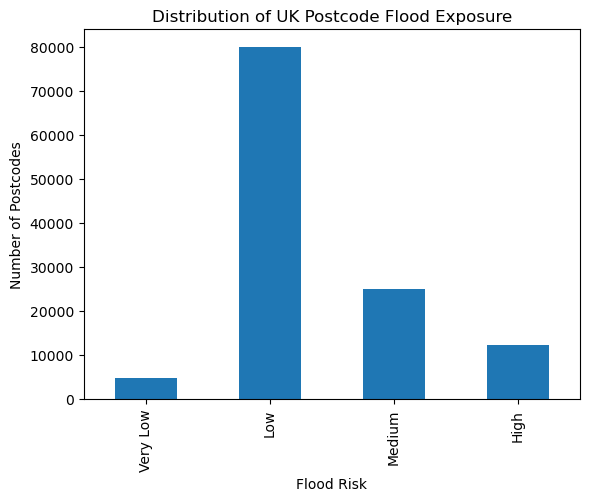

In [53]:
ax=risk_summary.plot(x="PROB_4BAND",y="Exposure",kind="bar",legend=False)

ax.set_xlabel("Flood Risk")
ax.set_ylabel("Number of Postcodes")
ax.set_title("Distribution of UK Postcode Flood Exposure")

plt.show()

The distribution demonstrates a clear concentration of postcode records within the low flood risk band, with exposure reducing steadily as flood probability increases. This indicates that high flood hazard exposure is not uniformly distributed but instead confined to a relatively small subset of locations. However, this potentially highlights the importance of identifying and managing accumulations of high-risk exposure, where a single flood event has the potential to generate disproportionate losses.

### SQL Analysis 2 – Spatial Distribution of High Flood Risk Locations

Whilst the previous SQL analysis quantified the distribution of flood risk categories, this analysis isolates only the highest flood risk locations before visualising their spatial distribution.

In [56]:
high_risk_query="""
SELECT
Latitude,
Longitude
FROM FloodRisk
WHERE PROB_4BAND='High';
"""

high_risk_locations=pd.read_sql_query(high_risk_query,connection)

high_risk_locations.head()

,Latitude,Longitude
0,50.128392,-5.676455
1,50.128465,-5.673858
2,50.128909,-5.672338
3,50.109733,-5.561400
4,50.109388,-5.560339


In [57]:
len(high_risk_locations)

12305

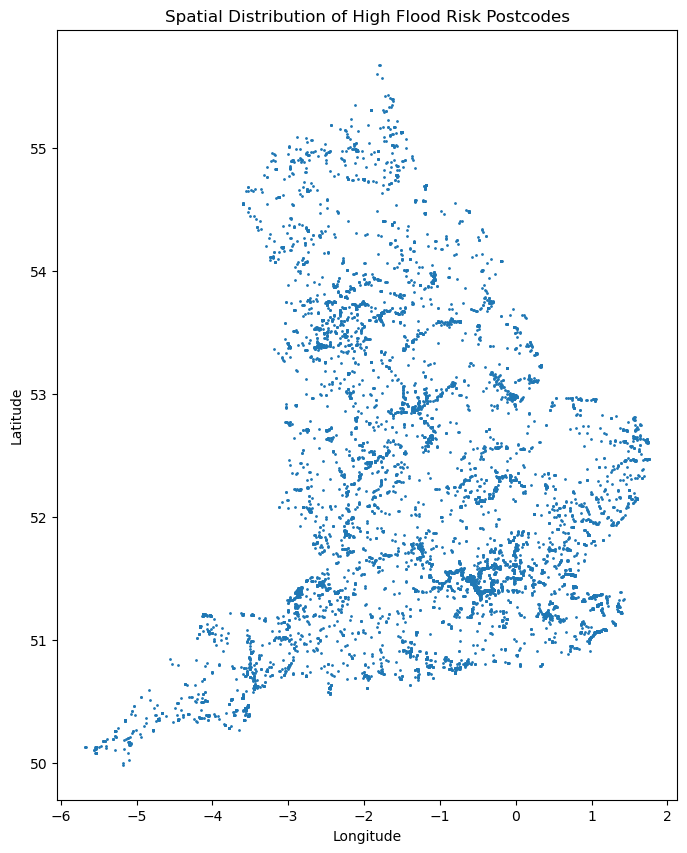

In [62]:
plt.figure(figsize=(8,10))

plt.scatter(
    high_risk_locations["Longitude"],
        high_risk_locations["Latitude"],
    s=1)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of High Flood Risk Postcodes")

plt.show()
        

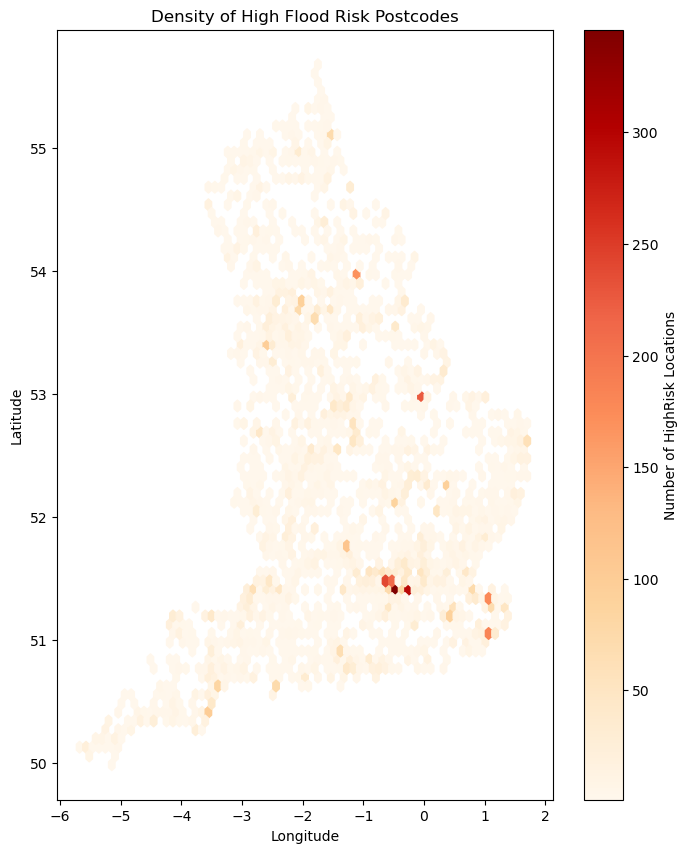

In [70]:
plt.figure(figsize=(8,10))

plt.hexbin(
    high_risk_locations["Longitude"],
    high_risk_locations["Latitude"],
    gridsize=70,
    cmap="OrRd",
    mincnt=1)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Density of High Flood Risk Postcodes")
plt.colorbar(label="Number of HighRisk Locations")

plt.show()

SQL was used to collect postcode records classified within the high flood risk category before importing the results into Python for geospatial visualisation. The density map highlights spatial clusterings of high-risk locations rather than an even national distribution. This reinforces the interpretation from SQL Analysis 1- geographically concentrated risks can significantly increase the potential portfolio impact of a single flood event.

### Flood Hazard Distribution

In [15]:
fr.describe(include='all')

,Postcode,FID,PROB_4BAND,SUITABILITY,PUB_DATE,Risk_For_Insurance_SOP,Easting,Northing,Latitude,Longitude
count,1443994,1443994,122007,1443994,1443994,1443994,1.443994e+06,1.443994e+06,1.443994e+06,1.443994e+06
unique,1443994,28959,4,6,20,3,NaN,NaN,NaN,NaN
top,TR23 0WA,\N,Low,\N,\N,\N,NaN,NaN,NaN,NaN
freq,1,1321987,80001,1321987,1321987,1321987,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,4.514074e+05,2.749507e+05,5.236327e+01,-1.252832e+00
std,NaN,NaN,NaN,NaN,NaN,NaN,8.767993e+04,1.307748e+05,1.180241e+00,1.268694e+00
min,NaN,NaN,NaN,NaN,NaN,NaN,8.790300e+04,8.478000e+03,4.989517e+01,-6.352609e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,3.899580e+05,1.732300e+05,5.144678e+01,-2.150858e+00
50%,NaN,NaN,NaN,NaN,NaN,NaN,4.463150e+05,2.524580e+05,5.215679e+01,-1.314460e+00
75%,NaN,NaN,NaN,NaN,NaN,NaN,5.234398e+05,3.898560e+05,5.340280e+01,-2.142255e-01


In [16]:
fr['PROB_4BAND'].value_counts()

PROB_4BAND
Low         80001
Medium      24928
High        12305
Very Low     4773
Name: count, dtype: int64

### Exposure Aggregation and Modelling
As insurance portfolio data is not publicly available, simulated insured property values are randomly assigned (£75,000 - £1,000,000) to demonstrate exposure management concepts.

Text(0, 0.5, 'Number of Postcodes')

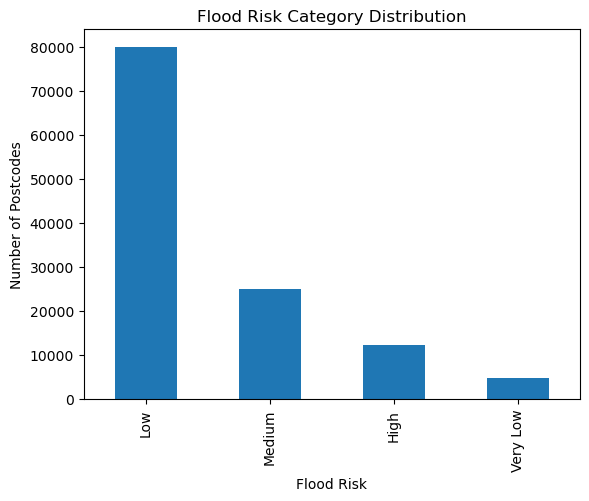

In [17]:
fr['PROB_4BAND'].value_counts().plot(kind='bar')

plt.title('Flood Risk Category Distribution')
plt.xlabel('Flood Risk')
plt.ylabel('Number of Postcodes')

Text(0, 0.5, 'Number of Postcodes')

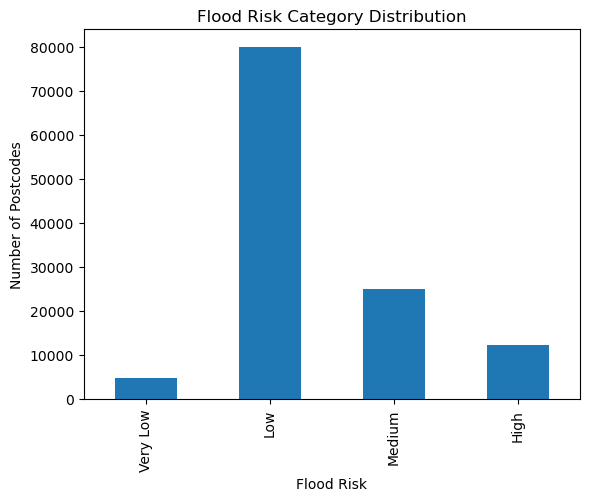

In [18]:
risk_order=['Very Low','Low','Medium','High']
risk_counts=fr['PROB_4BAND'].value_counts().reindex(risk_order)

risk_counts.plot(kind='bar')

plt.title('Flood Risk Category Distribution')
plt.xlabel('Flood Risk')
plt.ylabel('Number of Postcodes')

In [19]:
fr['Insured_Value']=np.random.randint(75000,1000000,size=len(fr))

In [20]:
risk_exposure=fr.groupby('PROB_4BAND')['Insured_Value'].sum()

print(risk_exposure)

PROB_4BAND
High         6527637974
Low         43075946190
Medium      13458032651
Very Low     2579537568
Name: Insured_Value, dtype: int64


Text(0.5, 0, 'Flood Risk')

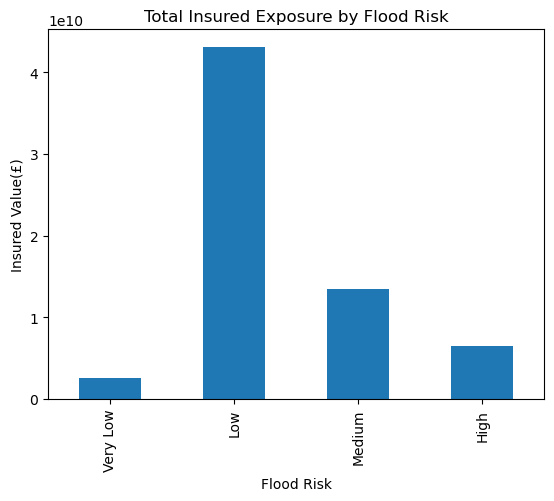

In [21]:
risk_order=['Very Low','Low','Medium','High']
risk_exposure=fr.groupby('PROB_4BAND')['Insured_Value'].sum().reindex(risk_order)

risk_exposure.plot(kind='bar')

plt.title('Total Insured Exposure by Flood Risk')
plt.ylabel('Insured Value(£)')
plt.xlabel('Flood Risk')

### Flood Loss Model

This loss model is applied using assumed damage ratios for each flood risk category. The values are:

| Flood Risk Category | Assumed Damage Ratio |
|---------------------|---------------------|
| High                | 10%                 |
| Medium              | 5%                  |
| Low                 | 2%                  |
| Very Low            | 0.5%                |

These assumptions are for the purposes of this workbook only and are not intended to represent real catastrophe model values.

In [22]:
loss_values={
    'High':0.10,
    'Medium':0.05,
    'Low':0.02,
    'Very Low':0.005}

In [23]:
fr['Loss']=fr['PROB_4BAND'].map(loss_values)

In [24]:
fr['Estimated_Loss']=fr['Insured_Value']*fr['Loss']

In [25]:
estimated_loss=fr.groupby('PROB_4BAND')['Estimated_Loss'].sum()

print(estimated_loss)

PROB_4BAND
High        6.527638e+08
Low         8.615189e+08
Medium      6.729016e+08
Very Low    1.289769e+07
Name: Estimated_Loss, dtype: float64


Text(0, 0.5, 'Estimated Loss(£)')

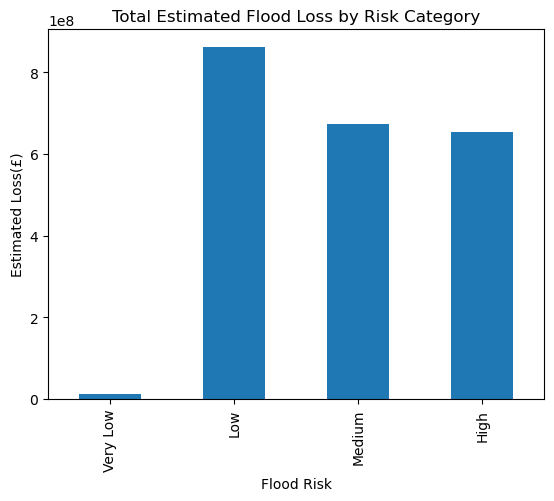

In [26]:
risk_order=['Very Low','Low','Medium','High']
estimated_loss=estimated_loss.reindex(risk_order)

estimated_loss.plot(kind='bar')

plt.title('Total Estimated Flood Loss by Risk Category')
plt.xlabel('Flood Risk')
plt.ylabel('Estimated Loss(£)')

Text(0, 0.5, '')

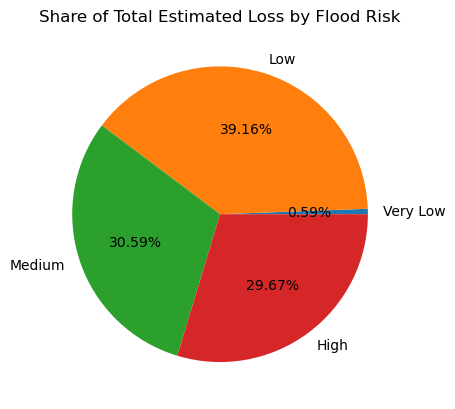

In [27]:
estimated_loss.plot(kind='pie',autopct='%1.2f%%')

plt.title('Share of Total Estimated Loss by Flood Risk')
plt.ylabel('')

Text(0, 0.5, '')

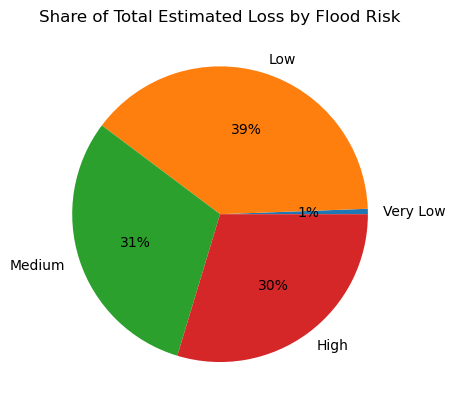

In [28]:
estimated_loss.plot(kind='pie',autopct='%1.0f%%')

plt.title('Share of Total Estimated Loss by Flood Risk')
plt.ylabel('')

### Exposure Concentrations
The following analysis identifies the postcode areas with the highest and lowest levels of insured exposure.

In [29]:
fr['Postcode_Area']=fr['Postcode'].str.split().str[0]

In [30]:
area_exposure=fr.groupby('Postcode_Area')['Insured_Value'].sum()

Text(0.5, 0, 'Insured Value (£)')

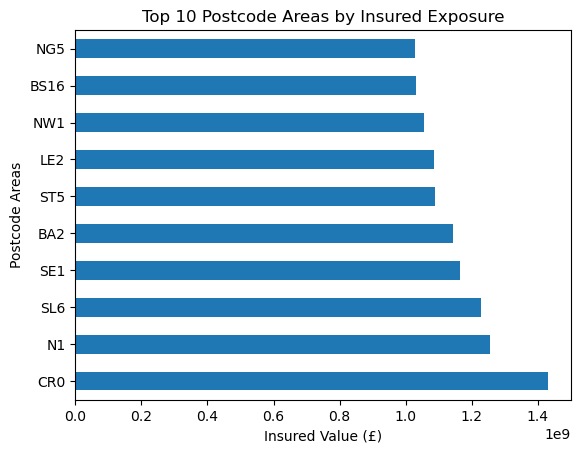

In [31]:
top10=area_exposure.sort_values(ascending=False).head(10)

top10.plot(kind='barh')

plt.title('Top 10 Postcode Areas by Insured Exposure')
plt.ylabel('Postcode Areas')
plt.xlabel('Insured Value (£)')

The above postcode areas represent the largest concentrations of insured exposure to flood risk. These postcodes may warrant further review for managing potential loss.

Text(0.5, 0, 'Insured Value (£)')

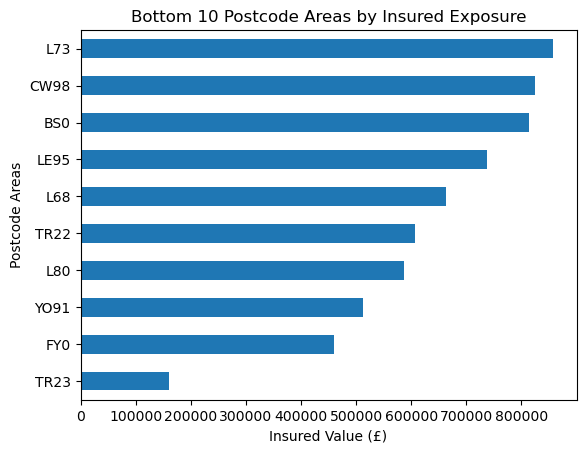

In [32]:
top10=area_exposure.sort_values(ascending=True).head(10)

top10.plot(kind='barh')

plt.title('Bottom 10 Postcode Areas by Insured Exposure')
plt.ylabel('Postcode Areas')
plt.xlabel('Insured Value (£)')

The above postcode areas contribute the least to the overall portfolio exposure. These postcodes therefore have a limited impact on loss potential.

### Full Distribution of Insurance Exposure using bins

Text(0, 0.5, 'Frequency')

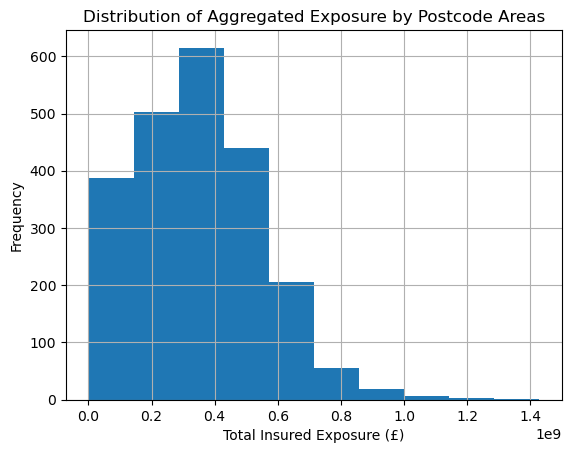

In [33]:
area_exposure.hist(bins=10)

plt.title('Distribution of Aggregated Exposure by Postcode Areas')
plt.xlabel('Total Insured Exposure (£)')
plt.ylabel('Frequency')

By narrowing the histogram bins to 10, the distribution of aggregated insured exposure becomes more clearly observable. The results indicate that the majority of postcode areas within the simulated portfolio contain relatively lower levels of aggregated insured exposure, while the frequency of postcode areas declines significantly as total exposure increases. This interpretation suggests a positively skewed exposure distribution, whereby a relatively small number of postcode areas contain disproportionately large concentrations of insured value. These higher concentration areas may represent greater risk during severe flood events, as shown when we combine this with the data of estimated losses- High Risk postcode areas, whilst distributed in a clear minority, present a disproportionately high contribution to potential loss.

### Simplified Catastrophe Loss Simulation

The previous sections estimated flood exposure and simulated insured values across UK postcodes. This section extends the analysis by generating a simplified catastrophe loss simulation.

Rather than estimating a single deterministic loss, random damage ratios are assigned according to each postcode's flood risk classification and repeated.

The resulting loss distribution is then used to estimate an illustrative Average Annual Loss (AAL) together with an illustrative Probable Maximum Loss (PML).

These results are intended solely to demonstrate catastrophe modelling concepts and should not be interpreted as representative of a commercial catastrophe model.

The following were simulated to produce an illustrative catastrophe loss simulation.

| Flood Risk | Mean Damage Ratio | Standard Deviation |
|------------|------------------:|-------------------:|
| Very Low | 0.3% | 0.1% |
| Low | 1.0% | 0.3% |
| Medium | 5.0% | 1.0% |
| High | 20.0% | 5.0% |

In [77]:
sim_df=fr[["PROB_4BAND","Insured_Value"]].copy()

sim_df=sim_df.dropna()

sim_df.head()

,PROB_4BAND,Insured_Value
250,High,979756
260,High,864750
271,High,197527
370,Low,993751
374,Low,474483


In [78]:
damage_ratios={
    "Very Low":(0.003,0.001),
    "Low":(0.01, 0.003),
    "Medium":(0.05, 0.01),
    "High":(0.20,0.05)}

damage_ratios

{'Very Low': (0.003, 0.001),
 'Low': (0.01, 0.003),
 'Medium': (0.05, 0.01),
 'High': (0.2, 0.05)}

In [79]:
eg=sim_df.iloc[0]

eg

PROB_4BAND         High
Insured_Value    979756
Name: 250, dtype: object

In [80]:
risk=eg["PROB_4BAND"]

risk

'High'

In [81]:
damage_ratios[risk]

(0.2, 0.05)

Mean Damage Ratio = 20%. Standard Deviation is 5%.

In [82]:
mean,std=damage_ratios[risk]

damage=np.random.normal(mean,std)

damage

0.2279213111428205

In [83]:
mean,std=damage_ratios[risk]

damage=np.random.normal(mean,std)

damage

0.1544281203322107

In [84]:
mean,std=damage_ratios[risk]

damage=np.random.normal(mean,std)

damage

0.25558841759677436

In [85]:
mean,std=damage_ratios[risk]

damage=np.random.normal(mean,std)

damage

0.2471432144449308

In [86]:
mean,std=damage_ratios[risk]

damage=np.random.normal(mean,std)

damage

0.0848146053661504

The random damage ratio generated above represents a single simulated flood event affecting one insured property.

The damage ratio changes each time the cell is executed because it is centred on the simulated damage ratio for that flood risk category. This reflects the uncertainty in 'real world' scenarios like flood events, where the severity of damage varies according to factors such as flood depth, duration, infrastructure quality/age and local conditions.

Generating different damage ratios for repeated simulations allows many flood scenarios to be explored rather than relying on a single fixed estimate.

In [88]:
insured=eg["Insured_Value"]

loss=insured*damage

loss

np.float64(83097.61849511805)

The simulated damage ratio has now been applied to the insured value of a single property to estimate an illustrative flood loss.

This (£83,097.62) represents the estimated financial impact of one hypothetical flood event affecting one insured location. Whilst only a single property has been modelled at this stage, the same methodology can subsequently be applied across the entire simulated portfolio and repeated thousands of times to generate a portfolio loss distribution from which Average Annual Loss (AAL) and Probable Maximum Loss (PML) metrics can be estimated.

### Conclusions

This project demonstrates a simplified catastrophe risk and exposure management workflow using publicly available UK postcode flood risk data. Python was used alongside SQL to clean, query and analyse the dataset before visualising flood hazard, exposure concentrations and simulated portfolio losses.

The analysis showed that the majority of UK postcodes fall within the **Very Low** and **Low** flood risk categories, with relatively few classified as **Medium** or **High** risk. This suggests that flood hazard is concentrated within a smaller number of locations rather than being evenly distributed across the country. From an insurance perspective, identifying these higher-risk concentrations is important, as they have the potential to generate disproportionately large losses during major flood events.

To build on this, a simplified loss simulation was developed using simulated insured values and illustrative damage ratios. Repeating the simulation using Monte Carlo methods demonstrated how metrics such as Average Annual Loss (AAL) and Probable Maximum Loss (PML) can be estimated from a portfolio. Although the assumptions used are simplified, they demonstrate the principles behind catastrophe loss modelling and exposure management.

### Limitations

- Insured values were simulated, as real insurance exposure data is not publicly available.
- Damage ratios were illustrative assumptions and were not based on historical claims data or vulnerability models.
- The simulation does not include individual flood events.
- The results should therefore be viewed as a demonstration of methodology rather than representative insurance losses.

### Future Improvements

There are several ways this project could be expanded in the future:

- Use realistic flood event sets rather than illustrative damage ratios.
- Produce interactive geospatial flood exposure maps.
- Incorporate property-level vulnerability values.
